# Calibrating Agricultural Water Demand in India with a Differentiable Agent-Based Model

This notebook implements a clean, lightweight version of the project proposed in `Project_proposal_Group_31.pdf`.

It follows the same core ideas:

- representative agricultural agents instead of simulating every farm
- soil-moisture dynamics with rainfall, evapotranspiration, and irrigation
- a differentiable farmer decision rule implemented in PyTorch
- gradient-based calibration against an observed water-demand proxy
- simple policy and climate scenario experiments

## Scope and simplifying assumptions

Because the project folder does not include ready-to-use district irrigation withdrawal data, this notebook uses a transparent proxy target for observed irrigation demand:

- crop-level water requirement from agronomic lookups
- annual rainfall split into season-specific effective rainfall
- gross irrigation demand derived from the remaining crop water deficit

This keeps the notebook faithful to the proposal while remaining fully runnable and understandable.


In [1]:
from pathlib import Path
import math
import warnings

import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_default_dtype(torch.float32)

DATA_URL = "https://raw.githubusercontent.com/h4ck3r0/crop-yielding-prediction/main/crop_yield.csv"
DATA_PATH = Path("data_crop_yield.csv")
NOTEBOOK_OUTPUT = Path("agri_water_demand_outputs")
NOTEBOOK_OUTPUT.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch version:", torch.__version__)
print("Data path:", DATA_PATH.resolve())


Torch version: 2.10.0+cpu
Data path: F:\IIT KGP\sem10\Stats in AIML\Course Project\data_crop_yield.csv


In [2]:
def download_data_if_needed(path: Path = DATA_PATH, url: str = DATA_URL) -> Path:
    if path.exists():
        print(f"Using existing dataset: {path} ({path.stat().st_size:,} bytes)")
        return path

    print("Downloading dataset...")
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    path.write_bytes(response.content)
    print(f"Saved dataset to: {path}")
    return path


download_data_if_needed()


Using existing dataset: data_crop_yield.csv (1,620,945 bytes)


WindowsPath('data_crop_yield.csv')

In [3]:
CROP_PARAMS = {
    "Rice": {"cwr_mm": 1200.0, "soil_capacity_mm": 220.0},
    "Wheat": {"cwr_mm": 550.0, "soil_capacity_mm": 160.0},
    "Maize": {"cwr_mm": 500.0, "soil_capacity_mm": 150.0},
    "Cotton(lint)": {"cwr_mm": 700.0, "soil_capacity_mm": 170.0},
    "Sugarcane": {"cwr_mm": 1600.0, "soil_capacity_mm": 260.0},
    "Jowar": {"cwr_mm": 450.0, "soil_capacity_mm": 140.0},
    "Soyabean": {"cwr_mm": 500.0, "soil_capacity_mm": 150.0},
    "Gram": {"cwr_mm": 400.0, "soil_capacity_mm": 135.0},
    "Bajra": {"cwr_mm": 350.0, "soil_capacity_mm": 130.0},
    "Arhar/Tur": {"cwr_mm": 600.0, "soil_capacity_mm": 150.0},
    "Rapeseed &Mustard": {"cwr_mm": 380.0, "soil_capacity_mm": 130.0},
    "Jute": {"cwr_mm": 650.0, "soil_capacity_mm": 160.0},
}

SEASON_RAIN_SHARE = {
    "Kharif": 0.75,
    "Rabi": 0.20,
    "Whole Year": 1.00,
    "Summer": 0.10,
    "Winter": 0.15,
    "Autumn": 0.25,
}

STATE_INFRA = {
    "Punjab": 0.90,
    "West Bengal": 0.72,
    "Maharashtra": 0.45,
}

TARGET_STATES = list(STATE_INFRA)


def load_and_prepare_data(path: Path = DATA_PATH) -> pd.DataFrame:
    df = pd.read_csv(path)

    df["State"] = df["State"].str.strip()
    df["Season"] = df["Season"].str.strip()
    df["Crop"] = df["Crop"].str.strip()

    df = df[df["State"].isin(TARGET_STATES)].copy()
    df = df[df["Crop"].isin(CROP_PARAMS)].copy()

    grouped = (
        df.groupby(["Crop_Year", "State", "Crop", "Season"], as_index=False)
        .agg(
            Area=("Area", "sum"),
            Production=("Production", "sum"),
            Annual_Rainfall=("Annual_Rainfall", "mean"),
            Fertilizer=("Fertilizer", "sum"),
            Pesticide=("Pesticide", "sum"),
            Yield=("Yield", "mean"),
        )
    )

    grouped["cwr_mm"] = grouped["Crop"].map(lambda x: CROP_PARAMS[x]["cwr_mm"])
    grouped["soil_capacity_mm"] = grouped["Crop"].map(lambda x: CROP_PARAMS[x]["soil_capacity_mm"])
    grouped["season_rain_share"] = grouped["Season"].map(SEASON_RAIN_SHARE).fillna(0.35)
    grouped["infra_score"] = grouped["State"].map(STATE_INFRA)
    grouped["application_efficiency"] = 0.52 + 0.12 * grouped["infra_score"]
    grouped["effective_rain_mm"] = 0.8 * grouped["Annual_Rainfall"] * grouped["season_rain_share"]
    grouped["yield_t_per_ha"] = grouped["Production"] / grouped["Area"].replace(0, np.nan)
    grouped["yield_t_per_ha"] = grouped["yield_t_per_ha"].replace([np.inf, -np.inf], np.nan).fillna(grouped["Yield"])
    grouped["input_cost_per_ha"] = (grouped["Fertilizer"] + grouped["Pesticide"]) / grouped["Area"].clip(lower=1.0)
    grouped["economic_signal"] = np.log1p(grouped["input_cost_per_ha"])

    grouped["proxy_net_irrigation_mm"] = np.maximum(
        grouped["cwr_mm"] - grouped["effective_rain_mm"], 0.0
    )
    grouped["target_water_demand_m3"] = (
        grouped["proxy_net_irrigation_mm"] * grouped["Area"] * 10.0 / grouped["application_efficiency"]
    )

    grouped["agent_key"] = grouped["State"] + " | " + grouped["Crop"] + " | " + grouped["Season"]
    grouped = grouped.sort_values(["agent_key", "Crop_Year"]).reset_index(drop=True)
    grouped["prev_idx"] = grouped.groupby("agent_key").cumcount() - 1
    grouped.loc[grouped["prev_idx"] < 0, "prev_idx"] = -1
    grouped["prev_idx"] = grouped.index.to_series().shift(1).where(
        grouped["agent_key"].eq(grouped["agent_key"].shift(1)),
        -1,
    ).astype(int)

    grouped["initial_soil_mm"] = np.minimum(
        0.25 * grouped["soil_capacity_mm"],
        0.15 * grouped["effective_rain_mm"],
    )

    grouped["bucket_key"] = grouped["State"] + " | " + grouped["Crop_Year"].astype(str)
    bucket_df = (
        grouped.groupby(["State", "Crop_Year"], as_index=False)["target_water_demand_m3"]
        .sum()
        .rename(columns={"target_water_demand_m3": "target_bucket_m3"})
    )
    bucket_df["bucket_id"] = np.arange(len(bucket_df))
    grouped = grouped.merge(bucket_df, on=["State", "Crop_Year"], how="left")

    train_cutoff = 2014
    grouped["split"] = np.where(grouped["Crop_Year"] <= train_cutoff, "train", "valid")
    bucket_df["split"] = np.where(bucket_df["Crop_Year"] <= train_cutoff, "train", "valid")

    return grouped, bucket_df


agent_df, bucket_df = load_and_prepare_data()

print("Agent-level rows:", len(agent_df))
print("State-year targets:", len(bucket_df))
display(agent_df.head())


Agent-level rows: 890
State-year targets: 69


,Crop_Year,State,Crop,Season,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,...,economic_signal,proxy_net_irrigation_mm,target_water_demand_m3,agent_key,prev_idx,initial_soil_mm,bucket_key,target_bucket_m3,bucket_id,split
0,1997,Maharashtra,Arhar/Tur,Kharif,1005600.0,348000,1156.1,95702952.0,311736.0,0.332500,...,4.569336,0.0,0.0,Maharashtra | Arhar/Tur | Kharif,-1,37.5,Maharashtra | 1997,3.586929e+10,0,train
1,1998,Maharashtra,Arhar/Tur,Kharif,1006700.0,808900,1314.8,99461960.0,291943.0,0.642500,...,4.606070,0.0,0.0,Maharashtra | Arhar/Tur | Kharif,0,37.5,Maharashtra | 1998,3.973245e+10,1,train
2,1999,Maharashtra,Arhar/Tur,Kharif,1040900.0,868100,1166.5,110470717.0,281043.0,0.706875,...,4.676560,0.0,0.0,Maharashtra | Arhar/Tur | Kharif,1,37.5,Maharashtra | 1999,4.565343e+10,2,train
3,2000,Maharashtra,Arhar/Tur,Kharif,1096100.0,660300,1057.8,107604137.0,284986.0,0.526563,...,4.599454,0.0,0.0,Maharashtra | Arhar/Tur | Kharif,2,37.5,Maharashtra | 2000,5.017252e+10,3,train
4,2001,Maharashtra,Arhar/Tur,Kharif,1017300.0,770600,1035.8,103896849.0,264498.0,0.627188,...,4.638508,0.0,0.0,Maharashtra | Arhar/Tur | Kharif,3,37.5,Maharashtra | 2001,5.290834e+10,4,train


,State,Crop,Total area
0,West Bengal,Rice,129455241.0
1,Maharashtra,Jowar,93936438.0
2,Punjab,Wheat,79694000.0
3,Maharashtra,Cotton(lint),78908059.0
4,Punjab,Rice,63430000.0
5,Maharashtra,Soyabean,58424954.0
6,Maharashtra,Rice,34801017.0
7,Maharashtra,Gram,28448729.0
8,Maharashtra,Bajra,26815484.4
9,West Bengal,Jute,13403803.0


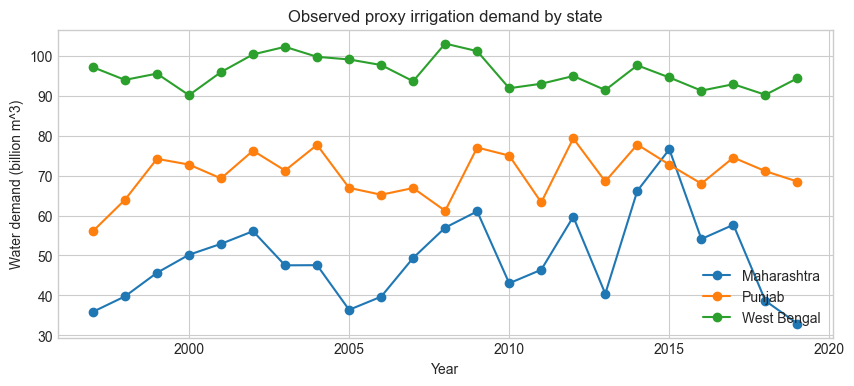

In [4]:
summary = (
    agent_df.groupby(["State", "Crop"])["Area"]
    .sum()
    .sort_values(ascending=False)
    .groupby(level=0)
    .head(6)
    .rename("Total area")
    .reset_index()
)

display(summary)

fig, ax = plt.subplots(figsize=(10, 4))
for state, sub in bucket_df.groupby("State"):
    ax.plot(sub["Crop_Year"], sub["target_bucket_m3"] / 1e9, marker="o", label=state)
ax.set_title("Observed proxy irrigation demand by state")
ax.set_ylabel("Water demand (billion m^3)")
ax.set_xlabel("Year")
ax.legend()
plt.show()


## Differentiable representative-agent ABM

Each row is treated as one representative farming agent for a `(state, crop, season, year)` combination.

For agent `i` in year `t`, the simplified dynamics are:

\[
SM_{i,t+1} = \text{clip}(\rho \cdot SM_{i,t} + R_{i,t}^{eff} + I_{i,t} - ET_{i,t}, 0, C_i)
\]

\[
I_{i,t} = \sigma(\beta_0 + \beta_1 d_{i,t} + \beta_2 r_{i,t} + \beta_3 e_{i,t} + \beta_4 y_{i,t} + \beta_5 q_i) \cdot I^{max}_{i}
\]

where:

- `d` is crop water deficit
- `r` is effective rainfall
- `e` is economic signal
- `y` is yield signal
- `q` is irrigation infrastructure score
- `rho` is the soil moisture retention parameter learned during calibration


In [5]:
def build_tensors(agent_df: pd.DataFrame, bucket_df: pd.DataFrame):
    feature_cols = [
        "effective_rain_mm",
        "economic_signal",
        "yield_t_per_ha",
        "infra_score",
        "cwr_mm",
        "soil_capacity_mm",
        "Area",
        "initial_soil_mm",
    ]

    train_mask_rows = agent_df["split"].eq("train")
    means = agent_df.loc[train_mask_rows, feature_cols].mean()
    stds = agent_df.loc[train_mask_rows, feature_cols].std().replace(0, 1.0)

    norm_df = agent_df.copy()
    for col in feature_cols:
        norm_df[f"{col}_z"] = (norm_df[col] - means[col]) / stds[col]

    tensors = {
        "rain_mm": torch.tensor(norm_df["effective_rain_mm"].values),
        "econ_z": torch.tensor(norm_df["economic_signal_z"].values),
        "yield_z": torch.tensor(norm_df["yield_t_per_ha_z"].values),
        "infra_z": torch.tensor(norm_df["infra_score_z"].values),
        "cwr_mm": torch.tensor(norm_df["cwr_mm"].values),
        "cwr_z": torch.tensor(norm_df["cwr_mm_z"].values),
        "soil_capacity_mm": torch.tensor(norm_df["soil_capacity_mm"].values),
        "area_ha": torch.tensor(norm_df["Area"].values),
        "initial_soil_mm": torch.tensor(norm_df["initial_soil_mm"].values),
        "prev_idx": torch.tensor(norm_df["prev_idx"].values, dtype=torch.long),
        "bucket_id": torch.tensor(norm_df["bucket_id"].values, dtype=torch.long),
    }

    bucket_targets = (
        bucket_df.sort_values("bucket_id")["target_bucket_m3"].values.astype(np.float32)
    )
    bucket_years = bucket_df.sort_values("bucket_id")["Crop_Year"].values
    bucket_states = bucket_df.sort_values("bucket_id")["State"].values
    bucket_split = bucket_df.sort_values("bucket_id")["split"].values

    metadata = {
        "row_df": norm_df,
        "bucket_targets": torch.tensor(bucket_targets),
        "bucket_years": bucket_years,
        "bucket_states": bucket_states,
        "bucket_split": bucket_split,
    }
    return tensors, metadata


tensors, metadata = build_tensors(agent_df, bucket_df)
num_rows = len(agent_df)
num_buckets = len(bucket_df)
print("Rows:", num_rows, "| Buckets:", num_buckets)


Rows: 890 | Buckets: 69


In [6]:
class DifferentiableWaterABM(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.tensor(0.0))
        self.beta_deficit = torch.nn.Parameter(torch.tensor(1.2))
        self.beta_rain = torch.nn.Parameter(torch.tensor(-0.8))
        self.beta_econ = torch.nn.Parameter(torch.tensor(0.4))
        self.beta_yield = torch.nn.Parameter(torch.tensor(0.25))
        self.beta_infra = torch.nn.Parameter(torch.tensor(0.35))
        self.retention_logit = torch.nn.Parameter(torch.tensor(0.2))
        self.rain_capture_logit = torch.nn.Parameter(torch.tensor(1.0))
        self.max_irrigation_scale_log = torch.nn.Parameter(torch.tensor(math.log(1.05)))

    def forward(self, tensors, overrides=None):
        overrides = overrides or {}

        rain_mm = overrides.get("rain_mm", tensors["rain_mm"])
        area_ha = tensors["area_ha"]
        prev_idx = tensors["prev_idx"]
        cwr_mm = tensors["cwr_mm"]
        soil_capacity_mm = tensors["soil_capacity_mm"]
        initial_soil_mm = tensors["initial_soil_mm"]
        econ_z = tensors["econ_z"]
        yield_z = tensors["yield_z"]
        infra_z = tensors["infra_z"]

        retention = torch.sigmoid(self.retention_logit)
        rain_capture = torch.sigmoid(self.rain_capture_logit)
        max_irrigation_scale = torch.exp(self.max_irrigation_scale_log)

        soil_next = []
        irrigation_mm = []

        for i in range(len(rain_mm)):
            if prev_idx[i].item() >= 0:
                prev_soil = soil_next[prev_idx[i].item()]
            else:
                prev_soil = initial_soil_mm[i]

            available_soil = torch.clamp(retention * prev_soil + rain_capture * rain_mm[i], min=0.0)
            deficit_mm = torch.clamp(cwr_mm[i] - available_soil, min=0.0)
            deficit_z = (deficit_mm - cwr_mm.mean()) / (cwr_mm.std() + 1e-6)
            rain_z = (rain_mm[i] - rain_mm.mean()) / (rain_mm.std() + 1e-6)

            logit = (
                self.bias
                + self.beta_deficit * deficit_z
                + self.beta_rain * rain_z
                + self.beta_econ * econ_z[i]
                + self.beta_yield * yield_z[i]
                + self.beta_infra * infra_z[i]
            )

            irr_mm = torch.sigmoid(logit) * max_irrigation_scale * cwr_mm[i]
            next_soil = torch.clamp(
                retention * prev_soil + rain_capture * rain_mm[i] + irr_mm - cwr_mm[i],
                min=0.0,
                max=soil_capacity_mm[i],
            )

            irrigation_mm.append(irr_mm)
            soil_next.append(next_soil)

        irrigation_mm = torch.stack(irrigation_mm)
        soil_next = torch.stack(soil_next)
        water_m3 = irrigation_mm * area_ha * 10.0

        if "cap_multiplier" in overrides:
            water_m3 = water_m3 * overrides["cap_multiplier"]

        return {
            "irrigation_mm": irrigation_mm,
            "soil_next_mm": soil_next,
            "water_m3": water_m3,
        }


def aggregate_to_buckets(row_values: torch.Tensor, bucket_id: torch.Tensor, n_buckets: int) -> torch.Tensor:
    bucket_values = torch.zeros(n_buckets, dtype=row_values.dtype)
    bucket_values.index_add_(0, bucket_id, row_values)
    return bucket_values


def fit_model(model, tensors, metadata, epochs=400, lr=0.07):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    target_bucket = metadata["bucket_targets"]
    split = metadata["bucket_split"]
    train_mask = torch.tensor(split == "train")
    valid_mask = torch.tensor(split == "valid")

    history = []

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        outputs = model(tensors)
        pred_bucket = aggregate_to_buckets(outputs["water_m3"], tensors["bucket_id"], len(target_bucket))

        train_loss = torch.mean(
            (torch.log1p(pred_bucket[train_mask]) - torch.log1p(target_bucket[train_mask])) ** 2
        )
        valid_loss = torch.mean(
            (torch.log1p(pred_bucket[valid_mask]) - torch.log1p(target_bucket[valid_mask])) ** 2
        )

        train_loss.backward()
        optimizer.step()

        history.append(
            {
                "epoch": epoch,
                "train_loss": float(train_loss.detach()),
                "valid_loss": float(valid_loss.detach()),
            }
        )

    return pd.DataFrame(history)


model = DifferentiableWaterABM()
history = fit_model(model, tensors, metadata)
history.tail()


,epoch,train_loss,valid_loss
395,396,0.000301,0.000632
396,397,0.000301,0.000632
397,398,0.000300,0.000632
398,399,0.000300,0.000631
399,400,0.000299,0.000631


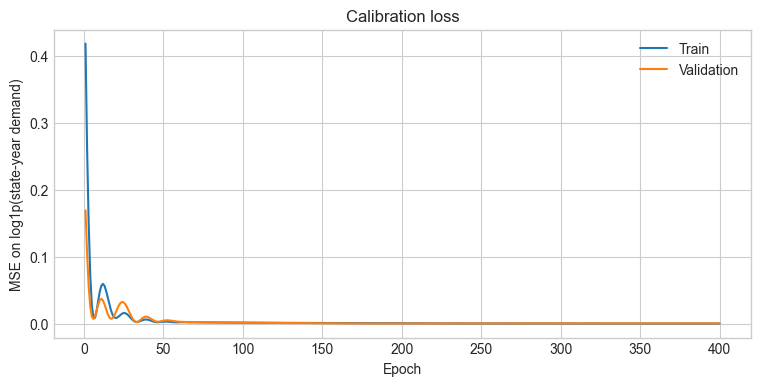

,value
beta_deficit,0.641285
beta_econ,0.012583
beta_infra,0.106948
beta_rain,-1.088701
beta_yield,-0.330544
bias,0.021501
max_irrigation_scale_log,0.529154
rain_capture_logit,1.097815
retention_logit,-0.687464


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history["epoch"], history["train_loss"], label="Train")
ax.plot(history["epoch"], history["valid_loss"], label="Validation")
ax.set_title("Calibration loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE on log1p(state-year demand)")
ax.legend()
plt.show()

learned_params = pd.Series(
    {name: float(param.detach()) for name, param in model.named_parameters()}
).sort_index()
display(learned_params.to_frame("value"))


In [8]:
with torch.no_grad():
    outputs = model(tensors)
    pred_bucket = aggregate_to_buckets(outputs["water_m3"], tensors["bucket_id"], len(metadata["bucket_targets"]))

results = bucket_df.sort_values("bucket_id").copy()
results["predicted_m3"] = pred_bucket.numpy()
results["target_m3"] = metadata["bucket_targets"].numpy()
results["abs_pct_error"] = (
    (results["predicted_m3"] - results["target_m3"]).abs() / results["target_m3"].clip(lower=1.0)
)

def regression_metrics(df):
    y_true = df["target_m3"].values
    y_pred = df["predicted_m3"].values
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs(y_pred - y_true) / np.clip(y_true, 1.0, None))
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    return pd.Series({"RMSE": rmse, "MAPE": mape, "Correlation": corr})


metric_table = results.groupby("split").apply(regression_metrics).reset_index()
display(metric_table)
display(results.head())


,split,RMSE,MAPE,Correlation
0,train,9.690277e+08,0.012441,0.998907
1,valid,1.323561e+09,0.016758,0.998869


,State,Crop_Year,target_bucket_m3,bucket_id,split,predicted_m3,target_m3,abs_pct_error
0,Maharashtra,1997,3.586929e+10,0,train,3.538534e+10,3.586929e+10,0.013492
1,Maharashtra,1998,3.973245e+10,1,train,3.941984e+10,3.973245e+10,0.007868
2,Maharashtra,1999,4.565343e+10,2,train,4.694387e+10,4.565343e+10,0.028266
3,Maharashtra,2000,5.017252e+10,3,train,5.055910e+10,5.017252e+10,0.007705
4,Maharashtra,2001,5.290834e+10,4,train,5.221488e+10,5.290834e+10,0.013107


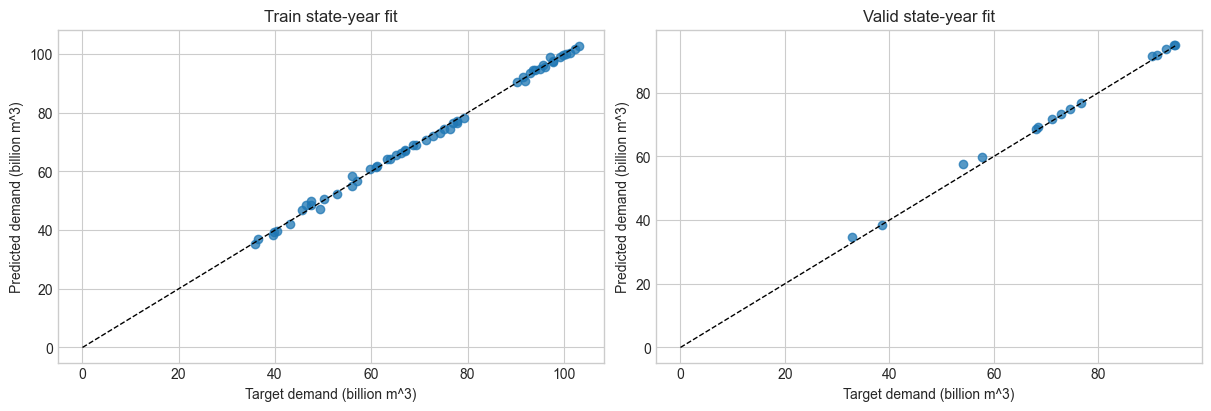

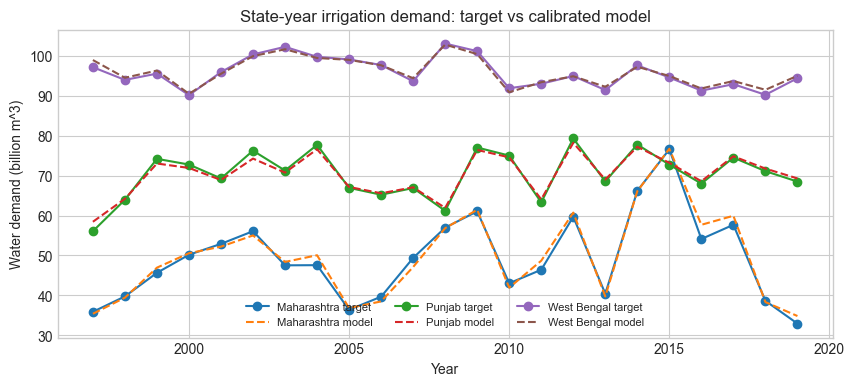

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for split, ax in zip(["train", "valid"], axes):
    sub = results[results["split"] == split]
    ax.scatter(sub["target_m3"] / 1e9, sub["predicted_m3"] / 1e9, alpha=0.75)
    lim = max(sub["target_m3"].max(), sub["predicted_m3"].max()) / 1e9
    ax.plot([0, lim], [0, lim], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{split.title()} state-year fit")
    ax.set_xlabel("Target demand (billion m^3)")
    ax.set_ylabel("Predicted demand (billion m^3)")

plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for state, sub in results.groupby("State"):
    ax.plot(sub["Crop_Year"], sub["target_m3"] / 1e9, marker="o", label=f"{state} target")
    ax.plot(sub["Crop_Year"], sub["predicted_m3"] / 1e9, linestyle="--", label=f"{state} model")
ax.set_title("State-year irrigation demand: target vs calibrated model")
ax.set_ylabel("Water demand (billion m^3)")
ax.set_xlabel("Year")
ax.legend(ncol=3, fontsize=8)
plt.show()


## Scenario analysis

Two simple scenarios are evaluated with the calibrated model:

1. `Monsoon shock`: effective Kharif rainfall falls by 15%
2. `Punjab groundwater cap`: all Punjab irrigation decisions are scaled down by 15%


In [10]:
def run_scenario(model, tensors, agent_df, rainfall_kharif_multiplier=1.0, punjab_cap_multiplier=1.0):
    rain_override = tensors["rain_mm"].clone()
    kharif_mask = torch.tensor(agent_df["Season"].eq("Kharif").values)
    rain_override[kharif_mask] = rain_override[kharif_mask] * rainfall_kharif_multiplier

    cap_multiplier = torch.ones(len(agent_df))
    punjab_mask = torch.tensor(agent_df["State"].eq("Punjab").values)
    cap_multiplier[punjab_mask] = punjab_cap_multiplier

    with torch.no_grad():
        outputs = model(
            tensors,
            overrides={"rain_mm": rain_override, "cap_multiplier": cap_multiplier},
        )
        pred_bucket = aggregate_to_buckets(outputs["water_m3"], tensors["bucket_id"], len(metadata["bucket_targets"]))

    out = bucket_df.sort_values("bucket_id").copy()
    out["scenario_predicted_m3"] = pred_bucket.numpy()
    return out


baseline = results[["State", "Crop_Year", "predicted_m3"]].rename(columns={"predicted_m3": "baseline_m3"})
monsoon_shock = run_scenario(model, tensors, agent_df, rainfall_kharif_multiplier=0.85, punjab_cap_multiplier=1.0)
groundwater_cap = run_scenario(model, tensors, agent_df, rainfall_kharif_multiplier=1.0, punjab_cap_multiplier=0.85)

scenario_compare = baseline.merge(
    monsoon_shock[["State", "Crop_Year", "scenario_predicted_m3"]],
    on=["State", "Crop_Year"],
    how="left",
).rename(columns={"scenario_predicted_m3": "monsoon_shock_m3"})

scenario_compare = scenario_compare.merge(
    groundwater_cap[["State", "Crop_Year", "scenario_predicted_m3"]],
    on=["State", "Crop_Year"],
    how="left",
).rename(columns={"scenario_predicted_m3": "groundwater_cap_m3"})

scenario_compare["monsoon_shock_change_pct"] = (
    100 * (scenario_compare["monsoon_shock_m3"] - scenario_compare["baseline_m3"]) / scenario_compare["baseline_m3"]
)
scenario_compare["groundwater_cap_change_pct"] = (
    100 * (scenario_compare["groundwater_cap_m3"] - scenario_compare["baseline_m3"]) / scenario_compare["baseline_m3"]
)

display(scenario_compare.tail(9))


,State,Crop_Year,baseline_m3,monsoon_shock_m3,groundwater_cap_m3,monsoon_shock_change_pct,groundwater_cap_change_pct
60,West Bengal,2011,9.343037e+10,9.250346e+10,9.343037e+10,-0.992084,0.0
61,West Bengal,2012,9.492344e+10,9.413873e+10,9.492344e+10,-0.826673,0.0
62,West Bengal,2013,9.228613e+10,9.102335e+10,9.228613e+10,-1.368332,0.0
63,West Bengal,2014,9.730316e+10,9.660236e+10,9.730316e+10,-0.720225,0.0
64,West Bengal,2015,9.498769e+10,9.398420e+10,9.498769e+10,-1.056444,0.0
65,West Bengal,2016,9.186111e+10,9.076867e+10,9.186111e+10,-1.189227,0.0
66,West Bengal,2017,9.372983e+10,9.258864e+10,9.372983e+10,-1.217530,0.0
67,West Bengal,2018,9.153073e+10,9.017576e+10,9.153073e+10,-1.480352,0.0
68,West Bengal,2019,9.503438e+10,9.400681e+10,9.503438e+10,-1.081260,0.0


,baseline_m3,monsoon_shock_m3,groundwater_cap_m3
State,,,
Maharashtra,53.503750,56.792281,53.503750
Punjab,71.553658,73.192701,60.820611
West Bengal,93.428747,92.304815,93.428747


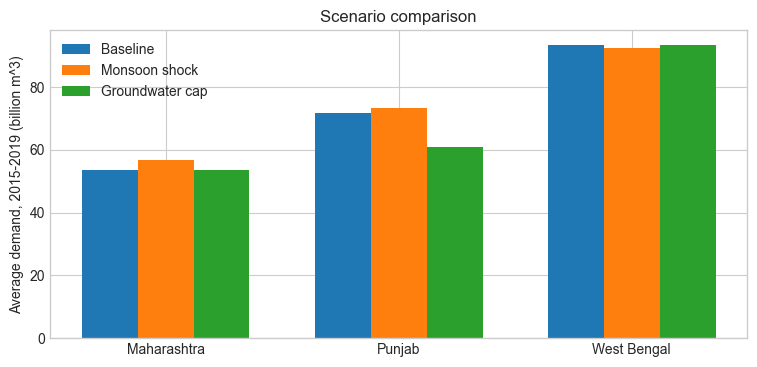

In [12]:
recent = scenario_compare[scenario_compare["Crop_Year"] >= 2015].copy()
scenario_summary = (
    recent.groupby("State")[["baseline_m3", "monsoon_shock_m3", "groundwater_cap_m3"]]
    .mean()
    / 1e9
)
display(scenario_summary)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(scenario_summary.index))
width = 0.24

ax.bar(x - width, scenario_summary["baseline_m3"], width=width, label="Baseline")
ax.bar(x, scenario_summary["monsoon_shock_m3"], width=width, label="Monsoon shock")
ax.bar(x + width, scenario_summary["groundwater_cap_m3"], width=width, label="Groundwater cap")

ax.set_xticks(x)
ax.set_xticklabels(scenario_summary.index)
ax.set_ylabel("Average demand, 2015-2019 (billion m^3)")
ax.set_title("Scenario comparison")
ax.legend()
plt.show()


## What this notebook delivers

- a representative-agent formulation for India-focused agricultural water demand
- a differentiable PyTorch ABM that can be calibrated with gradient descent
- interpretable irrigation behavior parameters
- state-level fit diagnostics for Punjab, West Bengal, and Maharashtra
- scenario analysis for climate stress and groundwater policy

## Natural extensions

- replace the proxy target with observed irrigation withdrawal or canal/groundwater extraction data
- add district-level agents instead of state-crop agents
- use monthly rainfall and evapotranspiration instead of seasonal rainfall shares
- replace the hand-crafted economic signal with market prices or MSP series
- move from this plain PyTorch implementation to AgentTorch or another dedicated D-ABM framework
